In [75]:
# ===== Import Libraries yang Digunakan =====

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import butter, filtfilt, find_peaks
from scipy.stats import zscore

In [76]:
# ===== Loading Data EKG =====

df = pd.read_csv("/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/Data Kalibrasi/120-2mV.csv")

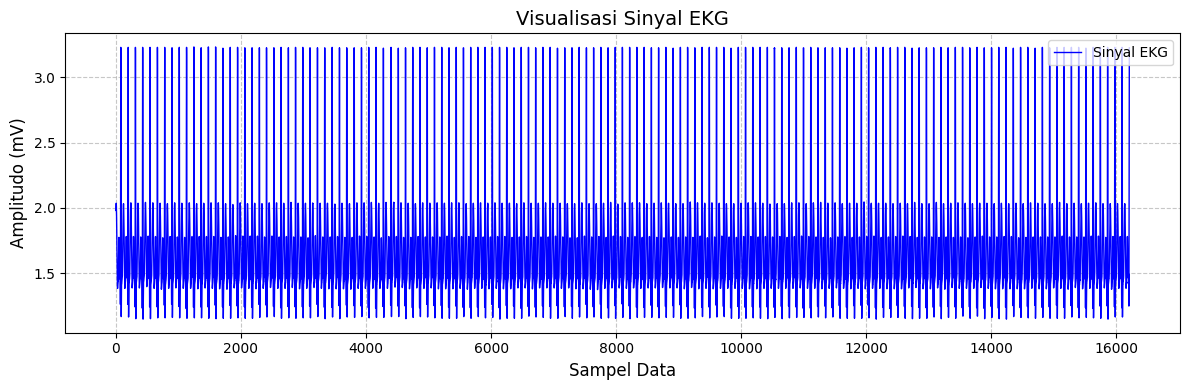

In [77]:
# ===== Visualisasi Sinyal EKG =====

ekg = df.iloc[:, 2]
fs = 250

waktu = range(len(ekg))
plt.figure(figsize=(12, 4))
plt.plot(waktu, ekg, color='b', linewidth=1.0, label='Sinyal EKG')
plt.title('Visualisasi Sinyal EKG', fontsize=14)
plt.xlabel('Sampel Data', fontsize=12)
plt.ylabel('Amplitudo (mV)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [78]:
# ===== Windowing Sinyal 10 Detik =====

def potong_jendela_10_detik(ekg, fs=250):
    ukuran_jendela = int(10 * fs)
    jendela_terkumpul = []

    for i in range(0,len(ekg) - ukuran_jendela + 1,ukuran_jendela):
        potongan = ekg[i : i + ukuran_jendela]
        jendela_terkumpul.append(potongan)
    return np.array(jendela_terkumpul)

matriks_jendela = potong_jendela_10_detik(ekg,fs=fs)
print("Jumlah window:", len(matriks_jendela))

Jumlah window: 6


=== Window 1 ===
BPM         : 128.76 BPM
Amplitudo P : 0.106 mV
Amplitudo R : 1.682 mV
Amplitudo T : 0.377 mV



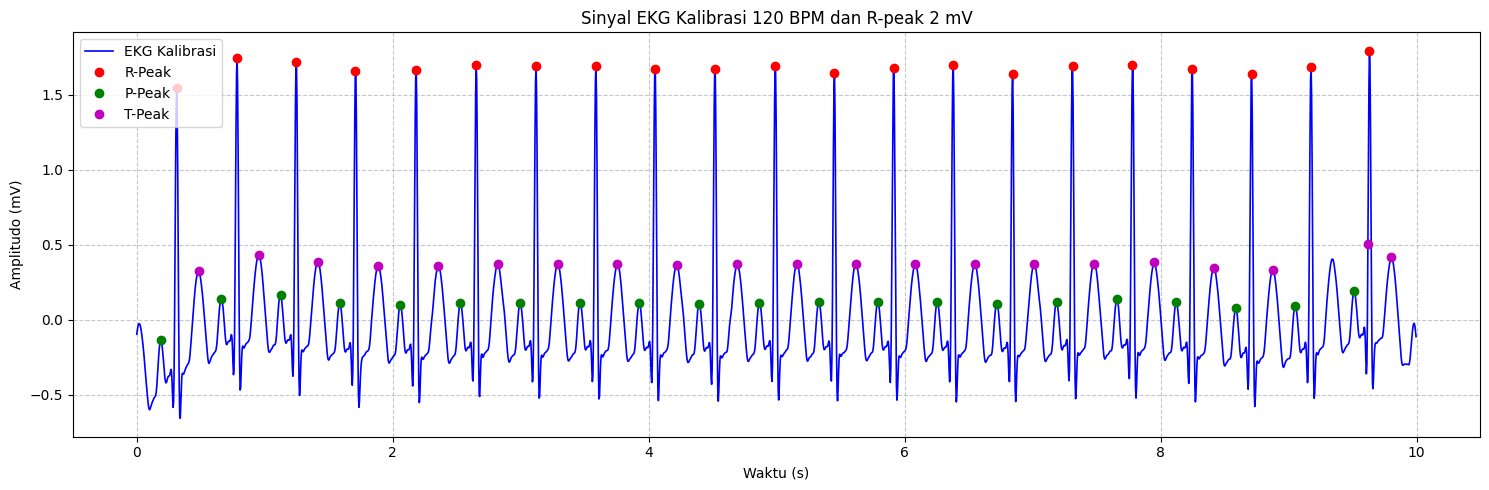

=== Window 2 ===
BPM         : 128.41 BPM
Amplitudo P : 0.138 mV
Amplitudo R : 1.711 mV
Amplitudo T : 0.374 mV



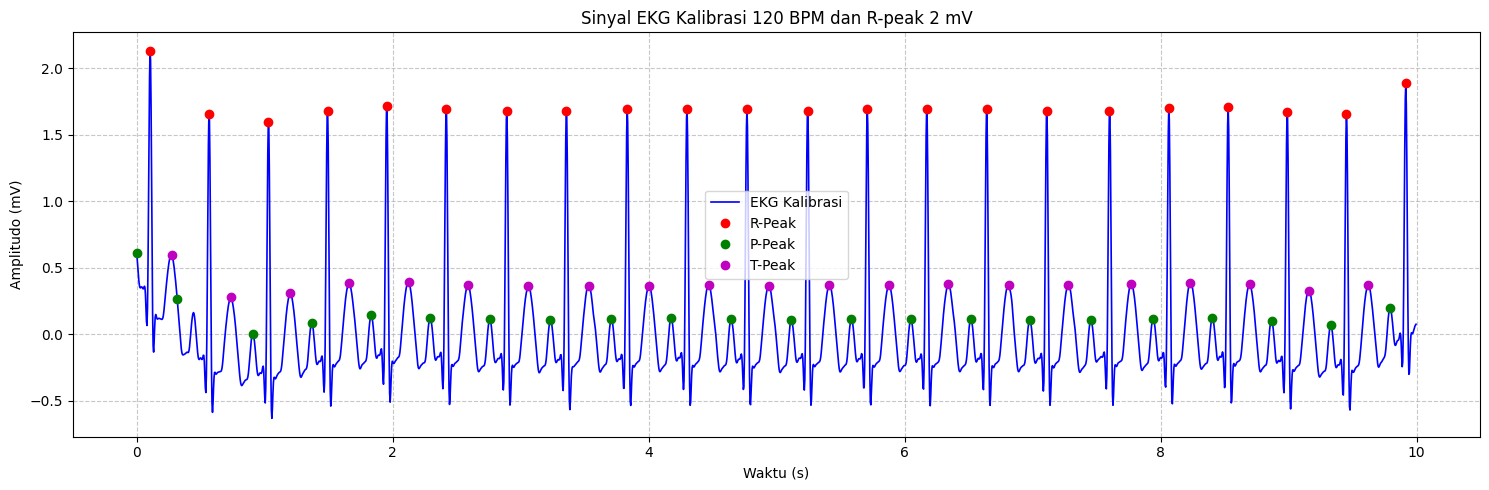

=== Window 3 ===
BPM         : 129.65 BPM
Amplitudo P : 0.118 mV
Amplitudo R : 1.690 mV
Amplitudo T : 0.371 mV



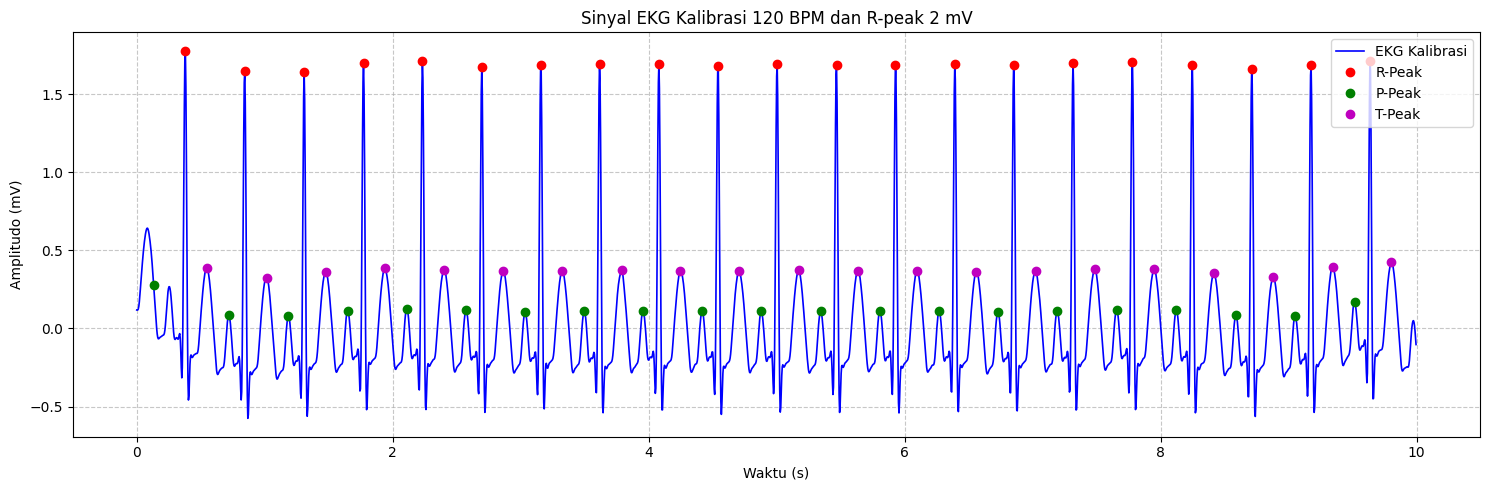

=== Window 4 ===
BPM         : 129.63 BPM
Amplitudo P : 0.135 mV
Amplitudo R : 1.704 mV
Amplitudo T : 0.360 mV



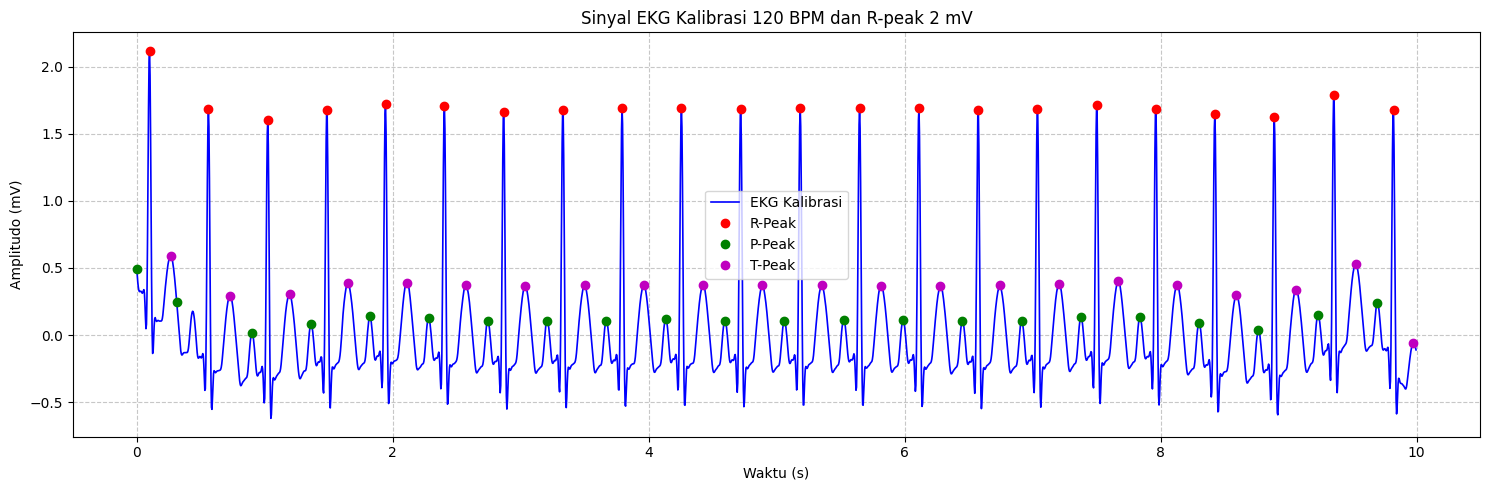

=== Window 5 ===
BPM         : 129.53 BPM
Amplitudo P : 0.104 mV
Amplitudo R : 1.686 mV
Amplitudo T : 0.388 mV



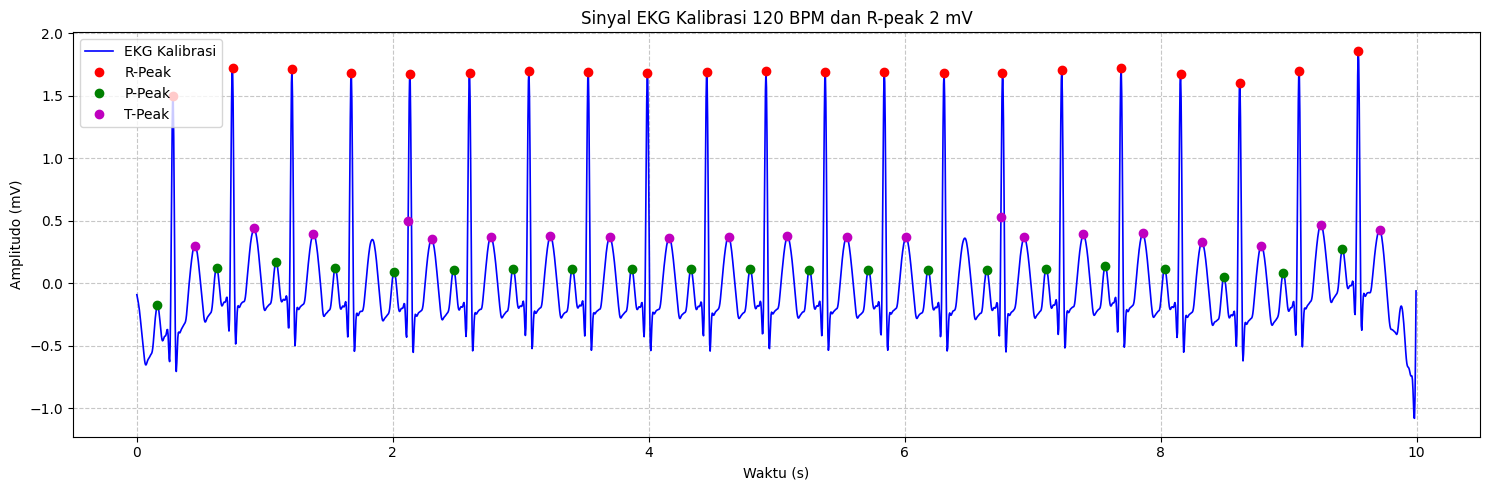

=== Window 6 ===
BPM         : 129.52 BPM
Amplitudo P : 0.096 mV
Amplitudo R : 1.620 mV
Amplitudo T : 0.371 mV



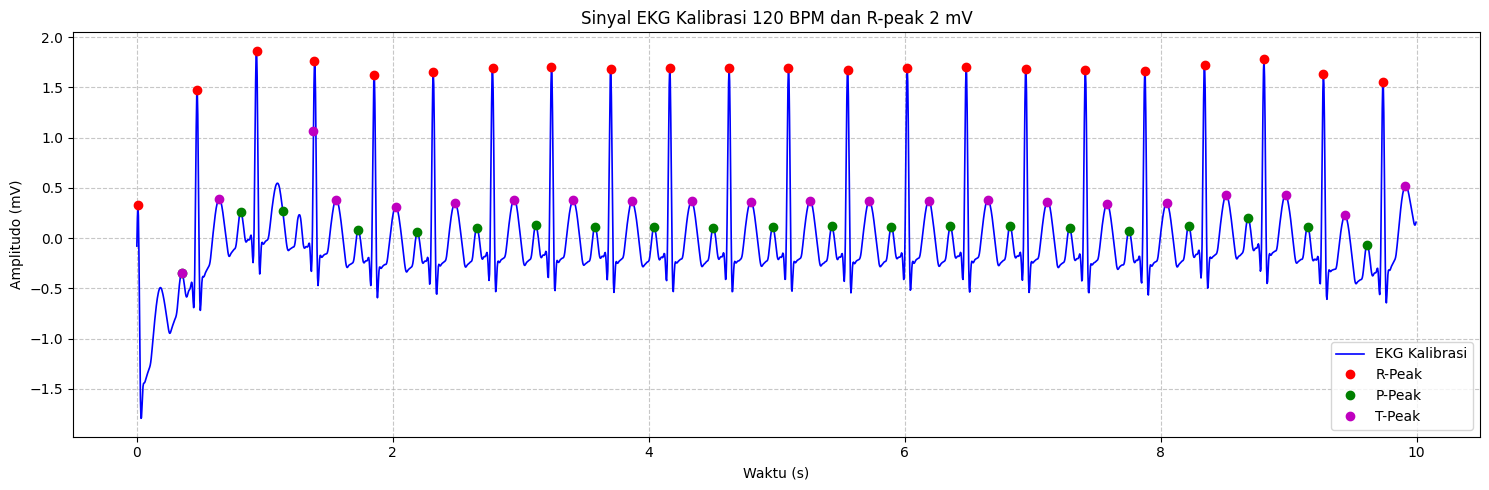


=== RATA-RATA KESELURUHAN ===
BPM Rata-rata : 129.25 BPM
Amp P Rata-rata: 0.116 mV
Amp R Rata-rata: 1.682 mV
Amp T Rata-rata: 0.373 mV


In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt

fs = 250  # Sampling rate

# Fungsi untuk Bandpass Filter
def apply_bandpass_filter(data, lowcut=0.5, highcut=40.0, fs=250, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    filtered_data = filtfilt(b, a, data)
    return filtered_data

# List untuk menyimpan rata-rata tiap window
all_bpm = []
all_amp_P = []
all_amp_R = []
all_amp_T = []

for window_ke in range(len(matriks_jendela)):
    signal_raw = matriks_jendela[window_ke]
    time = np.arange(len(signal_raw)) / fs
    signal_plot = apply_bandpass_filter(signal_raw, fs=fs)
    
    # 1. Deteksi R-Peaks & Hitung BPM
    min_dist = int(0.4 * fs)  
    threshold = np.mean(signal_plot) + 0.6 * np.std(signal_plot)
    
    r_peaks, _ = find_peaks(signal_plot, height=threshold, distance=min_dist)
    
    # Hitung BPM
    if len(r_peaks) > 1:
        rr_intervals = np.diff(r_peaks) / fs
        bpm = 60 / np.mean(rr_intervals)
    else:
        bpm = 0
        
    # 2. Deteksi Gelombang P dan T
    p_peaks = []
    t_peaks = []
    
    for r in r_peaks:
        # A. Cari Gelombang P
        # Rentang: 0.25 detik s.d 0.05 detik SEBELUM R-Peak
        start_p = max(0, r - int(0.25 * fs))
        end_p = max(0, r - int(0.05 * fs))
        
        if start_p < end_p:
            window_p = signal_plot[start_p:end_p]
            if len(window_p) > 0:
                idx_p_local = np.argmax(window_p)
                p_peaks.append(start_p + idx_p_local)
                
        # B. Cari Gelombang T 
        # Rentang: 0.15 detik s.d 0.45 detik SESUDAH R-Peak
        start_t = min(len(signal_plot), r + int(0.15 * fs))
        end_t = min(len(signal_plot), r + int(0.45 * fs))
        
        if start_t < end_t:
            window_t = signal_plot[start_t:end_t]
            if len(window_t) > 0:
                idx_t_local = np.argmax(window_t)
                t_peaks.append(start_t + idx_t_local)

    # Hitung Amplitudo Rata-rata dari sinyal yang sudah difilter
    mean_R = np.mean(signal_plot[r_peaks]) if len(r_peaks) > 0 else 0
    mean_P = np.mean(signal_plot[p_peaks]) if len(p_peaks) > 0 else 0
    mean_T = np.mean(signal_plot[t_peaks]) if len(t_peaks) > 0 else 0
    
    all_bpm.append(bpm)
    all_amp_R.append(mean_R)
    all_amp_P.append(mean_P)
    all_amp_T.append(mean_T)
    
    # 3. Print Hasil & Plot
    print(f"=== Window {window_ke + 1} ===")
    print(f"BPM         : {bpm:.2f} BPM")
    print(f"Amplitudo P : {mean_P:.3f} mV")
    print(f"Amplitudo R : {mean_R:.3f} mV")
    print(f"Amplitudo T : {mean_T:.3f} mV\n")
    
    plt.figure(figsize=(15,5))
    plt.plot(time, signal_plot, label='EKG Kalibrasi', color='blue', linewidth=1.2)
    
    # Plot Titik Puncak P, R, T pada sinyal yang difilter
    if len(r_peaks) > 0:
        plt.plot(time[r_peaks], signal_plot[r_peaks], "ro", markersize=6, label='R-Peak')
    if len(p_peaks) > 0:
        plt.plot(time[p_peaks], signal_plot[p_peaks], "go", markersize=6, label='P-Peak')
    if len(t_peaks) > 0:
        plt.plot(time[t_peaks], signal_plot[t_peaks], "mo", markersize=6, label='T-Peak')
        
    plt.title(f'Sinyal EKG Kalibrasi 120 BPM dan R-peak 2 mV')
    plt.xlabel('Waktu (s)')
    plt.ylabel('Amplitudo (mV)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Jika ingin melihat rata-rata keseluruhan window:
print("\n=== RATA-RATA KESELURUHAN ===")
print(f"BPM Rata-rata : {np.mean(all_bpm):.2f} BPM")
print(f"Amp P Rata-rata: {np.mean(all_amp_P):.3f} mV")
print(f"Amp R Rata-rata: {np.mean(all_amp_R):.3f} mV")
print(f"Amp T Rata-rata: {np.mean(all_amp_T):.3f} mV")